# 🔍 Notebook 4 — Outlier Detection & Handling

**Goal:** Find and handle abnormal data points that could confuse the ML model.
Outliers in petrol pump data could be: festival spikes, equipment failures, data entry errors.

**Methods used:**
1. IQR (Interquartile Range) method — simple statistical method
2. Z-Score method — standard deviation based
3. Isolation Forest — ML-based outlier detection
4. Visual inspection with box plots
5. Decision: cap outliers (winsorizing) vs remove vs keep

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/clean_data.csv', parse_dates=['Date'])
print(f'Loaded {len(df)} rows ✅')

# Columns to check for outliers
NUMERIC_COLS = ['Total_Sold', 'Opening_Stock', 'MS_Sold',
                'HSD1_Sold', 'HSD2_Sold', 'HSD3_Sold',
                'Cash', 'Online', 'Card']

Loaded 5189 rows ✅


## Step 1 — Box Plots to Visually Spot Outliers

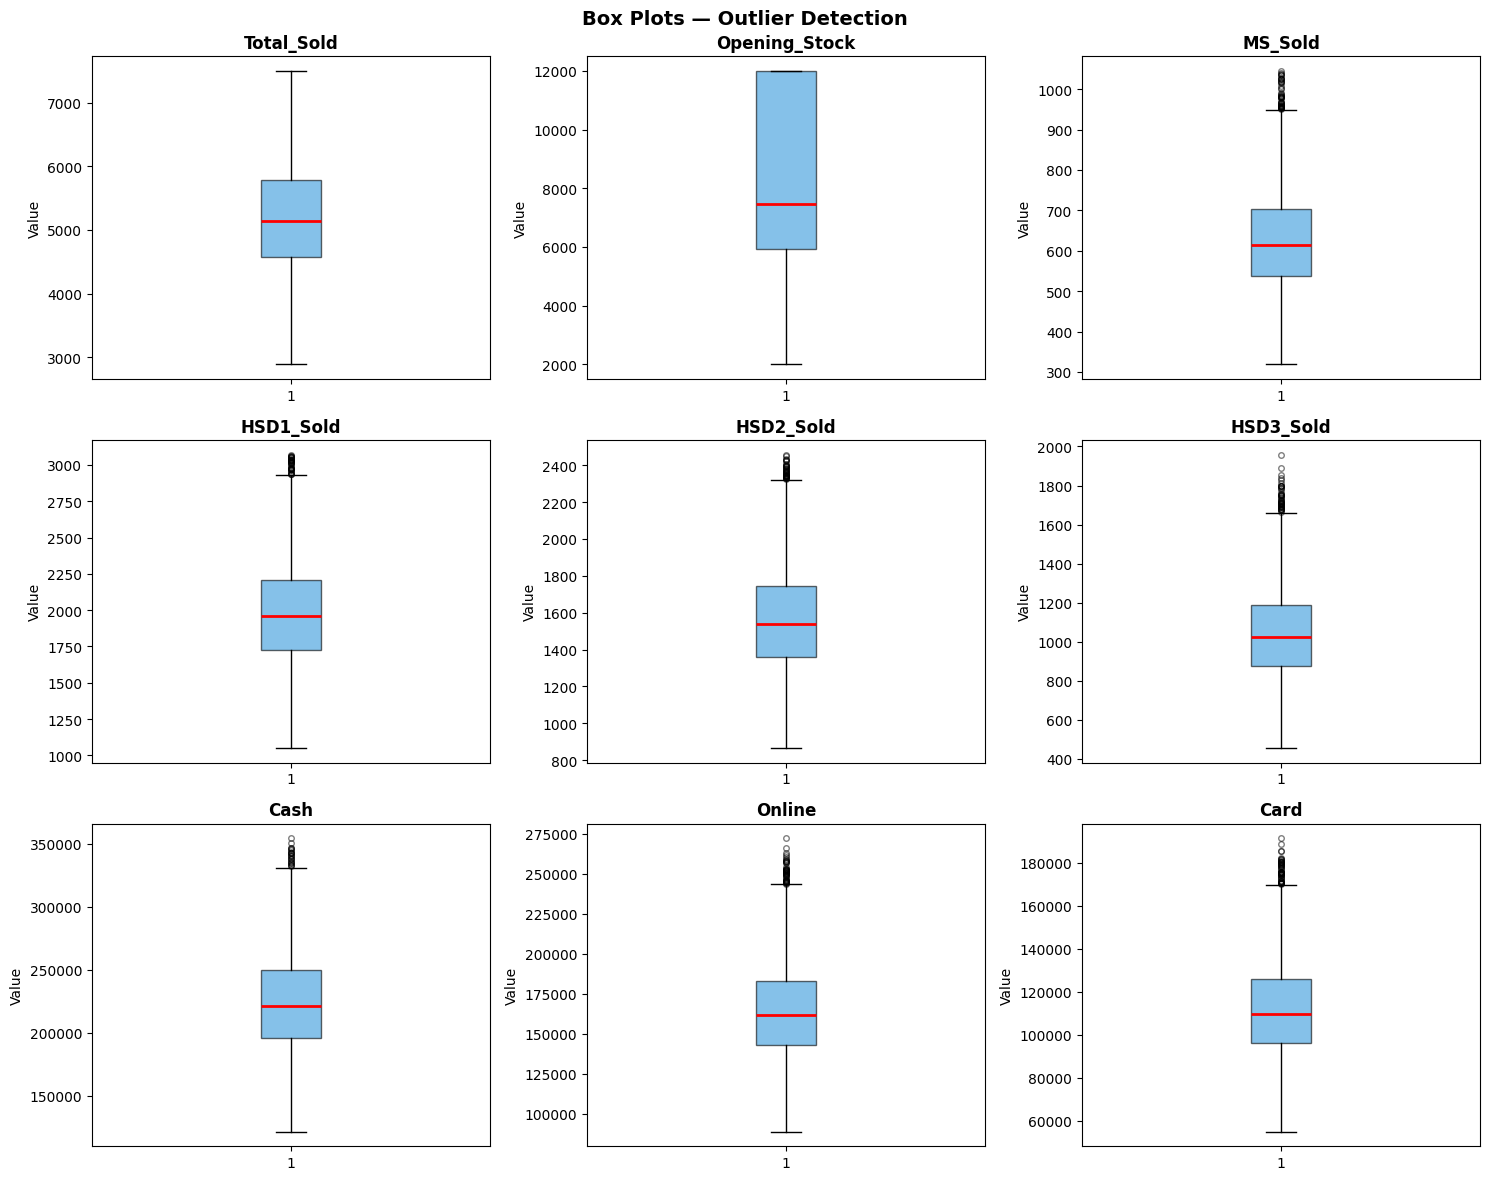

Red dots above/below the whiskers = outliers


In [2]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='red',
                                   markersize=4, alpha=0.5))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Box Plots — Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/viz_outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Red dots above/below the whiskers = outliers')

## Step 2 — IQR Method

In [3]:
# IQR method: outlier if value < Q1 - 1.5*IQR  or  > Q3 + 1.5*IQR
print('=== IQR Outlier Detection ===')
iqr_results = {}

for col in NUMERIC_COLS:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    iqr_results[col] = {
        'Lower_Bound': round(lower, 1),
        'Upper_Bound': round(upper, 1),
        'Outlier_Count': len(outliers),
        'Outlier_Pct': round(len(outliers) / len(df) * 100, 2)
    }
    print(f'{col:<20} | bounds: [{lower:.0f}, {upper:.0f}] | outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')

iqr_df = pd.DataFrame(iqr_results).T
print(f'\nTotal outlier rows (IQR): varies by column')

=== IQR Outlier Detection ===
Total_Sold           | bounds: [2754, 7614] | outliers: 0 (0.0%)
Opening_Stock        | bounds: [-3135, 21081] | outliers: 0 (0.0%)
MS_Sold              | bounds: [290, 950] | outliers: 44 (0.8%)
HSD1_Sold            | bounds: [1009, 2929] | outliers: 33 (0.6%)
HSD2_Sold            | bounds: [782, 2326] | outliers: 37 (0.7%)
HSD3_Sold            | bounds: [406, 1658] | outliers: 43 (0.8%)
Cash                 | bounds: [113464, 332064] | outliers: 23 (0.4%)
Online               | bounds: [82384, 243240] | outliers: 45 (0.9%)
Card                 | bounds: [52262, 169770] | outliers: 52 (1.0%)

Total outlier rows (IQR): varies by column


## Step 3 — Z-Score Method

In [4]:
# Z-Score: outlier if |z| > 3  (more than 3 standard deviations from mean)
print('=== Z-Score Outlier Detection (|z| > 3) ===')

zscore_outliers = pd.Series(False, index=df.index)

for col in NUMERIC_COLS:
    z = np.abs(stats.zscore(df[col].fillna(df[col].mean())))
    col_outliers = z > 3
    count = col_outliers.sum()
    zscore_outliers = zscore_outliers | col_outliers
    print(f'{col:<20} : {count} outliers ({count/len(df)*100:.2f}%)')

print(f'\nRows flagged by Z-Score in ANY column: {zscore_outliers.sum()} ({zscore_outliers.sum()/len(df)*100:.1f}%)')

=== Z-Score Outlier Detection (|z| > 3) ===
Total_Sold           : 0 outliers (0.00%)
Opening_Stock        : 0 outliers (0.00%)
MS_Sold              : 16 outliers (0.31%)
HSD1_Sold            : 14 outliers (0.27%)
HSD2_Sold            : 7 outliers (0.13%)
HSD3_Sold            : 23 outliers (0.44%)
Cash                 : 6 outliers (0.12%)
Online               : 13 outliers (0.25%)
Card                 : 20 outliers (0.39%)

Rows flagged by Z-Score in ANY column: 77 (1.5%)


## Step 4 — Isolation Forest (ML-based)

In [5]:
# Isolation Forest: learns what 'normal' looks like, flags anomalies
# contamination = expected % of outliers in dataset
X_iso = df[NUMERIC_COLS].fillna(0)

iso = IsolationForest(contamination=0.03, random_state=42, n_jobs=-1)
iso_preds = iso.fit_predict(X_iso)

# -1 = outlier, 1 = normal
df['Is_Outlier_IsoForest'] = (iso_preds == -1).astype(int)

n_outliers = df['Is_Outlier_IsoForest'].sum()
print(f'Isolation Forest found: {n_outliers} outliers ({n_outliers/len(df)*100:.1f}%)')

# Show what outliers look like
print('\nSample outlier rows:')
df[df['Is_Outlier_IsoForest'] == 1][NUMERIC_COLS + ['Refill_Required']].head(10)

Isolation Forest found: 156 outliers (3.0%)

Sample outlier rows:


,Total_Sold,Opening_Stock,MS_Sold,HSD1_Sold,HSD2_Sold,HSD3_Sold,Cash,Online,Card,Refill_Required
37,3467,12000,440,1389,1137,501,142547,106653,70052,No
160,3378,12000,440,1383,1099,456,150241,97318,75283,No
163,3428,12000,435,1299,1068,626,141121,98834,72014,No
164,3469,8572,393,1273,1138,665,150664,106207,67547,No
165,3133,5103,394,1104,900,735,135190,99873,55064,Yes
172,3409,12000,428,1311,1078,592,141342,109071,71420,No
177,3165,2733,347,1109,903,806,136825,107813,68272,Yes
178,3242,12000,341,1295,1046,560,134305,98512,61459,No
186,2995,4261,402,1131,868,594,132175,103942,65769,Yes
198,3412,2386,452,1392,1061,507,155422,108297,64542,Yes


## Step 5 — Visualize Outliers on Time Series

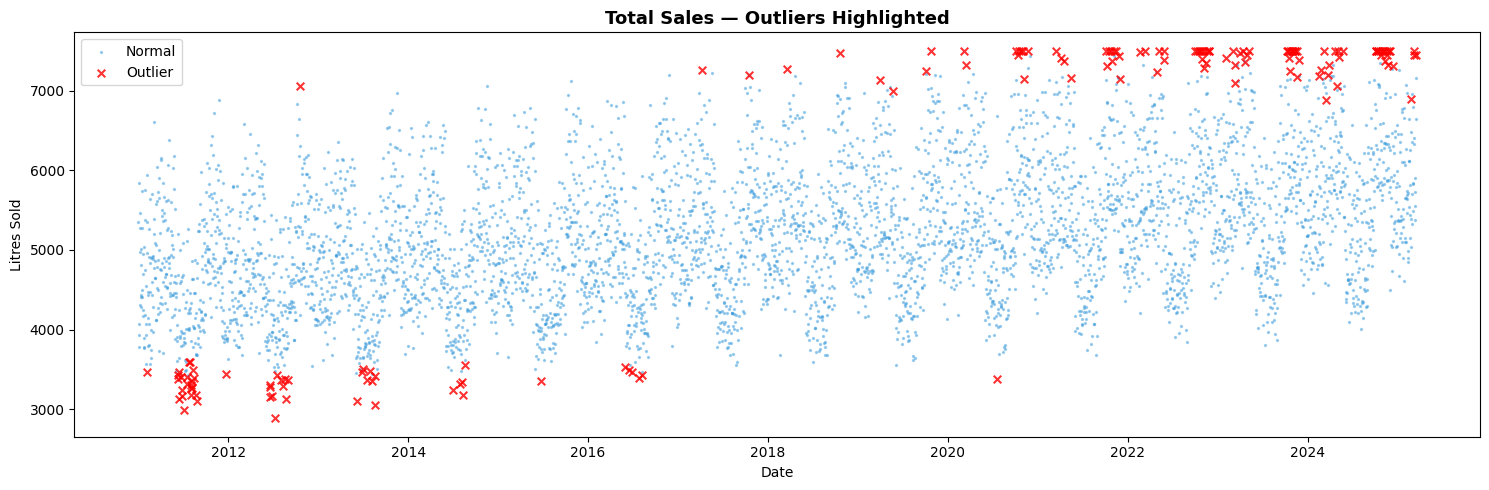

In [6]:
fig, ax = plt.subplots(figsize=(15, 5))

normal  = df[df['Is_Outlier_IsoForest'] == 0]
outlier = df[df['Is_Outlier_IsoForest'] == 1]

ax.scatter(normal['Date'], normal['Total_Sold'],
           s=2, alpha=0.4, color='#3498db', label='Normal')
ax.scatter(outlier['Date'], outlier['Total_Sold'],
           s=30, alpha=0.8, color='red', marker='x', label='Outlier', zorder=5)

ax.set_title('Total Sales — Outliers Highlighted', fontweight='bold', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Litres Sold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/viz_outliers_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Handle Outliers (Winsorizing / Capping)

In [7]:
# DECISION: We cap outliers using 1st and 99th percentile
# Why cap instead of remove?
#   → Removing rows loses data (we have enough)
#   → Capping preserves the row but limits extreme values
#   → Festival spikes are REAL events — we don't want to lose them

df_clean = df.copy()

CAP_COLS = ['Total_Sold', 'MS_Sold', 'HSD1_Sold', 'HSD2_Sold', 'HSD3_Sold']

for col in CAP_COLS:
    p01 = df_clean[col].quantile(0.01)
    p99 = df_clean[col].quantile(0.99)
    before_min = df_clean[col].min()
    before_max = df_clean[col].max()
    df_clean[col] = df_clean[col].clip(lower=p01, upper=p99)
    after_min = df_clean[col].min()
    after_max = df_clean[col].max()
    print(f'{col:<15} before: [{before_min:.0f}, {before_max:.0f}]  after: [{after_min:.0f}, {after_max:.0f}]')

# Drop the isolation forest flag column (not a real feature)
df_clean.drop(columns=['Is_Outlier_IsoForest'], inplace=True)

print(f'\nRows before: {len(df)}')
print(f'Rows after : {len(df_clean)}  (no rows dropped, only values capped)')

# Save
df_clean.to_csv('../data/clean_data_no_outliers.csv', index=False)
print('\n✅ Saved: data/clean_data_no_outliers.csv')

Total_Sold      before: [2887, 7500]  after: [3481, 7500]
MS_Sold         before: [319, 1045]  after: [393, 944]
HSD1_Sold       before: [1051, 3071]  after: [1313, 2860]
HSD2_Sold       before: [866, 2457]  after: [1031, 2280]
HSD3_Sold       before: [456, 1958]  after: [601, 1649]

Rows before: 5189
Rows after : 5189  (no rows dropped, only values capped)

✅ Saved: data/clean_data_no_outliers.csv
